# Experiment 10: Range Bound Population of DNNs with 10 Neurons Per Layer

In this experiment we perform range bounding on a population of DNNs and collect statistics over the population including:

* min / max range via numerical
* min / max range via Taylor
* min / max range via AMIE
* Overestimation of Taylor vs. numerical
* Overestimation of AMIE vs. numerical
* Runtime to generate AMIE coefs
* Runtime to range bound via AMIE
* N hidden nodes per layer (all layers the same)
* N Layers

All statistics are stored in a dataframe and plotted.


In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import time

from experiment_utils_range_bounding import (
    get_population_of_dnns,
    range_bound_dnn_numerical,
    range_bound_dnn_taylor_model
)

from prism.analysis import boxplot_utils

from verified_computing import taylorfactory

## Get a Population of Networks

In [2]:
n_per_group = 3

hidden_nodes_list = [
    (10,) * 2,
    (10,) * 3,
    (10,) * 4,
    (10,) * 5,
    (10,) * 6,
]

inputs_list = [3,]

activation_list = ['tanh', ] # 'tanh', 'relu'

In [3]:
population, metadata_df = get_population_of_dnns(
    n_per_group,
    hidden_nodes_list,
    inputs_list,
    activation_list,
    lr=0.01,
    momentum=0.1,
    rho=0.9,
    eps=1e-06,
    betas=(0.9, 0.99),
    use_gpu=True,
    optimizer_method='adam',
    weight_decay=0.01,
)

In [4]:
print('Generated {} networks:'.format(len(metadata_df)))
metadata_df.head()


Generated 15 networks:


,activation,n_inputs,n_hidden_nodes_per_layer,n_layers
0,tanh,3,10,3
1,tanh,3,10,3
2,tanh,3,10,3
3,tanh,3,10,4
4,tanh,3,10,4


## Loop through the population and perform range bounding

For each network in the population, range bounding is performed over increasingly large interval sizes.  The range bounding procedure first involves performing a numerical heuristic analysis to obtain appropriate suggested v_max values.  Then the network is bounded via both Taylor and AMIE polynomials.  The overestimation of the Taylor and AMIE polynomials range bounding procuedures vs. the numerical procedure is tabulated.  Runtime to build the AMIE polynomials and to perform the range bounding is recorded sepparately.


In [5]:
# Prepare a results dataframe
results_columns = [
    'activation',
    'n_inputs',
    'n_hidden_nodes_per_layer',
    'n_layers',
    'min_range_numerical',
    'max_range_numerical',
    'min_range_taylor',
    'max_range_taylor',
    'min_range_amie',
    'max_range_amie',
    'overestimation_taylor',
    'overestimation_amie',
    'runtime_to_generate_amie_coefs',
    'runtime_to_range_bound_via_amie',
    'domain_interval_width'
]

# Prepare a list of interval widths to analyze
interval_widths = [
    0.01,
    0.1,
    0.5,
    1,
    1.5,
    2,
]

n_points_numerical = 100

# Taylor model parameters
big_m = 6
dps = 65
tol_finalization_step = 1e-6
n_subdomains = 100

In [6]:
results_list = []

for idx, network in enumerate(population):

    print('\nPerforming range analysis on network {}\n'.format(idx))
 
    for interval_width in interval_widths:

        print('  * Analyzing domain width {}'.format(interval_width))

        # 1) Obtain a domain interval to analyze
        x_min = - interval_width / 2.0
        x_max = interval_width / 2.0

        # 2) Perform initial range bounding numerically
        y_min_numer, y_max_numer, v_min_list, v_max_list = \
            range_bound_dnn_numerical(
                network, x_min, x_max, n_points_numerical)

        # 3) Obtain a guess for v_max using the numerical results
        v_min = np.min(v_min_list)
        v_max = np.max(v_max_list)
        v_max = 1.5*np.max([np.abs(v_min), np.abs(v_max)])

        # 4) Obtain a Taylor model for the given v_max
        activation_type = metadata_df.loc[idx, 'activation']

        if activation_type == 'relu':
            t0 = time.time()
            t_amie = taylorfactory.get_taylor_model(
                function_type='relu',
                big_m=big_m,
                v_max=v_max,
                dps=dps,
                silent=True,
                n_brute_points=250,
                tol_final=tol_finalization_step
            )
            t1 = time.time()
            time_to_generate_amie_polynomials = t1 - t0

            print('  * AMIE ReLU model error: {}', t_amie.error.tostr())

            # Cannot construct a conventional Taylor model for ReLU
            t_taylor = None

        elif activation_type == 'tanh':
            t0 = time.time()
            t_amie = taylorfactory.get_taylor_model(
                function_type='tanh',
                big_m=big_m,
                v_max=v_max,
                dps=dps,
                silent=True,
                n_brute_points=100,
                tol_final=tol_finalization_step
            )
            t1 = time.time()
            time_to_generate_amie_polynomials = t1 - t0

            print('  * AMIE Tanh model error: {}', t_amie.error.tostr())

            t_taylor = taylorfactory.get_taylor_model(
                function_type='tanh_taylor',
                big_m=big_m,
                v_max=v_max,
                dps=dps,
                silent=True,
                n_brute_points=100,
                tol_final=tol_finalization_step
            )

            print('  * AMIE Tanh model error: {}', t_amie.error.tostr())

        # 5) Use the given Taylor models to perform range bounding
        y_min_taylor, y_max_taylor, v_list_taylor = range_bound_dnn_taylor_model(
            network, t_taylor, x_min, x_max, n_subdomains
        )

        t0 = time.time()
        y_min_amie, y_max_amie, v_list_amie = range_bound_dnn_taylor_model(
            network, t_amie, x_min, x_max, n_subdomains
        )
        t1 = time.time()
        time_to_range_bound_amie = t1 - t0

        # 6) Compare range bounds with numerical bounds
        width_numer = y_max_numer - y_min_numer
        width_taylor = y_max_taylor - y_min_taylor
        width_amie = y_max_amie - y_min_amie

        overestimate_taylor = width_taylor - width_numer
        overestimate_amie = width_amie - width_numer

        # 7) Store metrics
        results_row = [
            activation_type,
            metadata_df.loc[idx, 'n_inputs'],
            metadata_df.loc[idx, 'n_hidden_nodes_per_layer'],
            metadata_df.loc[idx, 'n_layers'],
            y_min_numer,
            y_max_numer,
            y_min_taylor,
            y_max_taylor,
            y_min_amie,
            y_max_amie,
            overestimate_taylor,
            overestimate_amie,
            time_to_generate_amie_polynomials,
            time_to_range_bound_amie,
            interval_width
        ]

        results_list.append(results_row)

results_df = pd.DataFrame(results_list, columns=results_columns)


Performing range analysis on network 0

  * Analyzing domain width 0.01
  * AMIE Tanh model error: {} [[-9.38955462e-06], [9.38955463e-06]]
  * AMIE Tanh model error: {} [[-9.38955462e-06], [9.38955463e-06]]
  * Analyzing domain width 0.1
  * AMIE Tanh model error: {} [[-1.9846156e-05], [1.9846156e-05]]
  * AMIE Tanh model error: {} [[-1.9846156e-05], [1.9846156e-05]]
  * Analyzing domain width 0.5
  * AMIE Tanh model error: {} [[-0.00027236], [0.00027236]]
  * AMIE Tanh model error: {} [[-0.00027236], [0.00027236]]
  * Analyzing domain width 1
  * AMIE Tanh model error: {} [[-0.00262879], [0.00262879]]
  * AMIE Tanh model error: {} [[-0.00262879], [0.00262879]]
  * Analyzing domain width 1.5
  * AMIE Tanh model error: {} [[-0.00864667], [0.00864667]]
  * AMIE Tanh model error: {} [[-0.00864667], [0.00864667]]
  * Analyzing domain width 2
  * AMIE Tanh model error: {} [[-0.01696562], [0.01696562]]
  * AMIE Tanh model error: {} [[-0.01696562], [0.01696562]]

Performing range analysis o

c:\users\sanch\engineering\projects\verified_computing\src\verified_computing\intvmath.py:752: RuntimeWarning: overflow encountered in power
  interval_result.x1 = interval.x1 ** integer_exponent_odd
c:\users\sanch\engineering\projects\verified_computing\src\verified_computing\intvmath.py:753: RuntimeWarning: overflow encountered in power
  interval_result.x2 = interval.x2 ** integer_exponent_odd



Performing range analysis on network 5

  * Analyzing domain width 0.01
  * AMIE Tanh model error: {} [[-5.62786951e-06], [5.62786951e-06]]
  * AMIE Tanh model error: {} [[-5.62786951e-06], [5.62786951e-06]]
  * Analyzing domain width 0.1
  * AMIE Tanh model error: {} [[-1.40116375e-05], [1.40116375e-05]]
  * AMIE Tanh model error: {} [[-1.40116375e-05], [1.40116375e-05]]
  * Analyzing domain width 0.5
  * AMIE Tanh model error: {} [[-0.00021319], [0.00021319]]
  * AMIE Tanh model error: {} [[-0.00021319], [0.00021319]]
  * Analyzing domain width 1
  * AMIE Tanh model error: {} [[-0.00201326], [0.00201326]]
  * AMIE Tanh model error: {} [[-0.00201326], [0.00201326]]
  * Analyzing domain width 1.5
  * AMIE Tanh model error: {} [[-0.0073574], [0.0073574]]
  * AMIE Tanh model error: {} [[-0.0073574], [0.0073574]]
  * Analyzing domain width 2
  * AMIE Tanh model error: {} [[-0.01498169], [0.01498169]]
  * AMIE Tanh model error: {} [[-0.01498169], [0.01498169]]

Performing range analysis o

c:\users\sanch\engineering\projects\verified_computing\src\verified_computing\intvmath.py:704: RuntimeWarning: overflow encountered in power
  interval_result.x1 = interval.x2 ** integer_exponent_even
c:\users\sanch\engineering\projects\verified_computing\src\verified_computing\intvmath.py:705: RuntimeWarning: overflow encountered in power
  interval_result.x2 = interval.x1 ** integer_exponent_even
c:\users\sanch\engineering\projects\verified_computing\src\verified_computing\intvmath.py:640: RuntimeWarning: invalid value encountered in multiply
  x1_result_candidate1 = interval_a.x1 * interval_b.x1
c:\users\sanch\engineering\projects\verified_computing\src\verified_computing\intvmath.py:641: RuntimeWarning: invalid value encountered in multiply
  x1_result_candidate2 = interval_a.x1 * interval_b.x2
c:\users\sanch\engineering\projects\verified_computing\src\verified_computing\intvmath.py:642: RuntimeWarning: invalid value encountered in multiply
  x1_result_candidate3 = interval_a.x2 * 

  * Analyzing domain width 2
  * AMIE Tanh model error: {} [[-0.01110273], [0.01110273]]
  * AMIE Tanh model error: {} [[-0.01110273], [0.01110273]]


c:\users\sanch\engineering\projects\verified_computing\src\verified_computing\intvmath.py:704: RuntimeWarning: overflow encountered in square
  interval_result.x1 = interval.x2 ** integer_exponent_even
c:\users\sanch\engineering\projects\verified_computing\src\verified_computing\intvmath.py:705: RuntimeWarning: overflow encountered in square
  interval_result.x2 = interval.x1 ** integer_exponent_even
c:\users\sanch\engineering\projects\verified_computing\src\verified_computing\intvmath.py:714: RuntimeWarning: overflow encountered in square
  interval.x1 ** integer_exponent_even,
c:\users\sanch\engineering\projects\verified_computing\src\verified_computing\intvmath.py:715: RuntimeWarning: overflow encountered in square
  interval.x2 ** integer_exponent_even,
c:\users\sanch\engineering\projects\verified_computing\src\verified_computing\intvmath.py:729: RuntimeWarning: overflow encountered in square
  interval_result.x1 = interval.x1 ** integer_exponent_even
c:\users\sanch\engineering\pro


Performing range analysis on network 7

  * Analyzing domain width 0.01
  * AMIE Tanh model error: {} [[-1.03018502e-05], [1.03018502e-05]]
  * AMIE Tanh model error: {} [[-1.03018502e-05], [1.03018502e-05]]
  * Analyzing domain width 0.1
  * AMIE Tanh model error: {} [[-1.64944073e-05], [1.64944073e-05]]
  * AMIE Tanh model error: {} [[-1.64944073e-05], [1.64944073e-05]]
  * Analyzing domain width 0.5
  * AMIE Tanh model error: {} [[-7.994011e-05], [7.994011e-05]]
  * AMIE Tanh model error: {} [[-7.994011e-05], [7.994011e-05]]
  * Analyzing domain width 1
  * AMIE Tanh model error: {} [[-0.0012237], [0.0012237]]
  * AMIE Tanh model error: {} [[-0.0012237], [0.0012237]]
  * Analyzing domain width 1.5
  * AMIE Tanh model error: {} [[-0.00454269], [0.00454269]]
  * AMIE Tanh model error: {} [[-0.00454269], [0.00454269]]
  * Analyzing domain width 2
  * AMIE Tanh model error: {} [[-0.01043346], [0.01043346]]
  * AMIE Tanh model error: {} [[-0.01043346], [0.01043346]]

Performing range an

C:\Users\sanch\anaconda3\envs\cuda111\lib\site-packages\numpy\core\function_base.py:146: RuntimeWarning: invalid value encountered in multiply
  y = y * step
C:\Users\sanch\anaconda3\envs\cuda111\lib\site-packages\numpy\core\function_base.py:154: RuntimeWarning: invalid value encountered in add
  y += start


  * Analyzing domain width 2
  * AMIE Tanh model error: {} [[-0.02430823], [0.02430823]]
  * AMIE Tanh model error: {} [[-0.02430823], [0.02430823]]

Performing range analysis on network 10

  * Analyzing domain width 0.01
  * AMIE Tanh model error: {} [[-2.53457427e-06], [2.53457427e-06]]
  * AMIE Tanh model error: {} [[-2.53457427e-06], [2.53457427e-06]]
  * Analyzing domain width 0.1
  * AMIE Tanh model error: {} [[-4.06670213e-06], [4.06670213e-06]]
  * AMIE Tanh model error: {} [[-4.06670213e-06], [4.06670213e-06]]
  * Analyzing domain width 0.5
  * AMIE Tanh model error: {} [[-5.05925359e-05], [5.05925359e-05]]
  * AMIE Tanh model error: {} [[-5.05925359e-05], [5.05925359e-05]]
  * Analyzing domain width 1
  * AMIE Tanh model error: {} [[-0.00043651], [0.00043651]]
  * AMIE Tanh model error: {} [[-0.00043651], [0.00043651]]
  * Analyzing domain width 1.5
  * AMIE Tanh model error: {} [[-0.00428489], [0.00428489]]
  * AMIE Tanh model error: {} [[-0.00428489], [0.00428489]]
  * Ana

In [7]:
# Copy the original dataframe
results_df_orign = results_df.copy(deep=True)

results_df.head()

,activation,n_inputs,n_hidden_nodes_per_layer,n_layers,min_range_numerical,max_range_numerical,min_range_taylor,max_range_taylor,min_range_amie,max_range_amie,overestimation_taylor,overestimation_amie,runtime_to_generate_amie_coefs,runtime_to_range_bound_via_amie,domain_interval_width
0,tanh,3,10,3,-0.333091,-0.330813,[-0.34034452247447383],[-0.3234425217012655],[-0.3393592947038033],[-0.32442324221372315],[0.014624103562242585],[0.012658155279114403],0.736164,0.463000,0.01
1,tanh,3,10,3,-0.342569,-0.321292,[-0.4082910226796441],[-0.2548320098596029],[-0.40591579065144257],[-0.2572115121975422],[0.13218221258985624],[0.12742747822371542],0.714222,0.471964,0.10
2,tanh,3,10,3,-0.386290,-0.274350,[-0.7544850713525365],[0.1083630719651375],[-0.6853926960748133],[0.03693837849852405],[0.7509085324608816],[0.610391463716545],1.081238,0.490188,0.50
3,tanh,3,10,3,-0.412326,-0.206754,[-225.53886984709231],[124.25493693536157],[-0.9723276374282188],[0.3580580845553294],[349.5882348543883],[1.1248137939179805],1.100967,0.482742,1.00
4,tanh,3,10,3,-0.472647,-0.155841,[-11745487034638.238],[10543407976227.088],[-1.1795771692912997],[0.5988100057933019],[22288895010865.01],[1.461581033870653],1.432650,0.498504,1.50


In [8]:
# Remove outliers due to Taylor divergence
inf_threshold = 28
results_df.loc[results_df['overestimation_taylor'] > inf_threshold, 'overestimation_taylor'] = np.inf

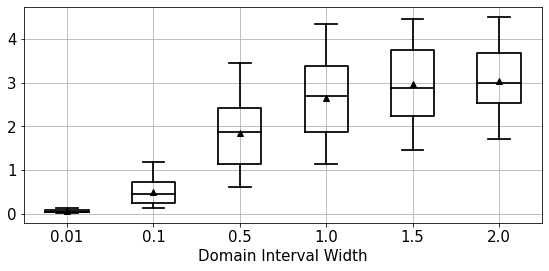

In [9]:
boxplot_utils.make_boxplot(
    'plots/overestimation_wrt_interval_width_amie.png',
    results_df,
    xcol='domain_interval_width', ycol='overestimation_amie',
    lw=1.75, color='k',
    figsize=(9,4), fontsize=15,
    xlabel='Domain Interval Width')

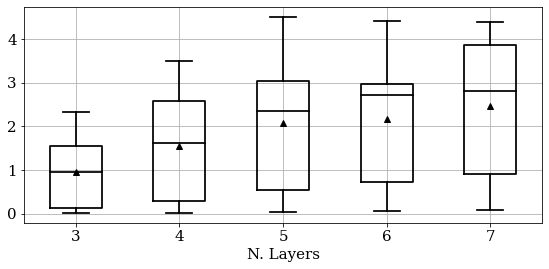

In [10]:
boxplot_utils.make_boxplot(
    'plots/overestimation_wrt_n_layers_amie.png',
    results_df,
    xcol='n_layers', ycol='overestimation_amie',
    lw=1.75, color='k',
    figsize=(9,4), fontsize=15,
    xlabel='N. Layers')

C:\Users\sanch\anaconda3\envs\cuda111\lib\site-packages\numpy\lib\function_base.py:3968: RuntimeWarning: invalid value encountered in multiply
  x2 = take(ap, indices_above, axis=axis) * weights_above
C:\Users\sanch\anaconda3\envs\cuda111\lib\site-packages\matplotlib\cbook\__init__.py:1211: RuntimeWarning: invalid value encountered in less_equal
  wiskhi = x[x <= hival]
C:\Users\sanch\anaconda3\envs\cuda111\lib\site-packages\matplotlib\cbook\__init__.py:1218: RuntimeWarning: invalid value encountered in greater_equal
  wisklo = x[x >= loval]


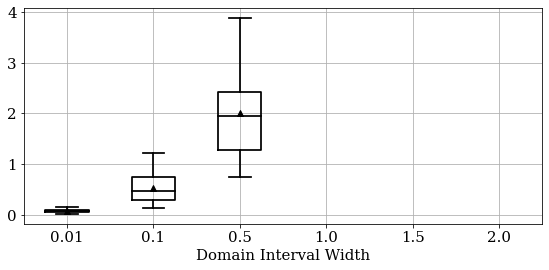

In [11]:
boxplot_utils.make_boxplot(
    'plots/overestimation_wrt_interval_width_taylor.png',
    results_df,
    xcol='domain_interval_width', ycol='overestimation_taylor',
    lw=1.75, color='k',
    figsize=(9,4), fontsize=15,
    xlabel='Domain Interval Width')

C:\Users\sanch\anaconda3\envs\cuda111\lib\site-packages\matplotlib\cbook\__init__.py:1128: RuntimeWarning: invalid value encountered in subtract
  notch_min = med - 1.57 * iqr / np.sqrt(N)
C:\Users\sanch\anaconda3\envs\cuda111\lib\site-packages\numpy\core\_asarray.py:136: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray
  return array(a, dtype, copy=False, order=order, subok=True)
C:\Users\sanch\anaconda3\envs\cuda111\lib\site-packages\numpy\core\_asarray.py:136: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray
  return array(a, dtype, copy=False, order=order, s

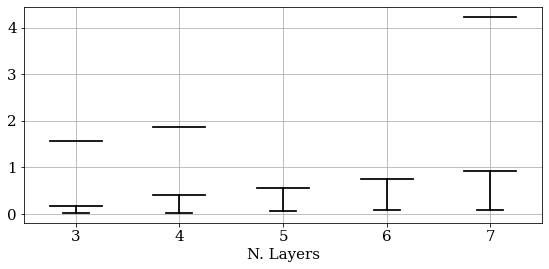

In [12]:
boxplot_utils.make_boxplot(
    'plots/overestimation_wrt_n_layers_taylor.png',
    results_df,
    xcol='n_layers', ycol='overestimation_taylor',
    lw=1.75, color='k',
    figsize=(9,4), fontsize=15,
    xlabel='N. Layers')

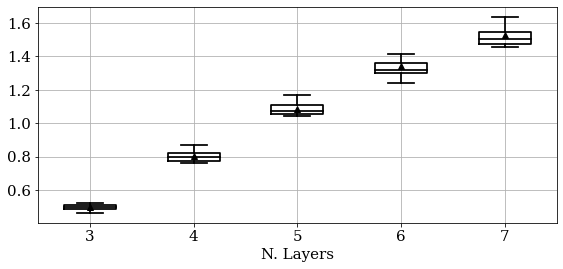

In [13]:

boxplot_utils.make_boxplot(
    'plots/runtime_range_bound_wrt_n_layers.png',
    results_df,
    xcol='n_layers', ycol='runtime_to_range_bound_via_amie',
    lw=1.75, color='k',
    figsize=(9,4), fontsize=15,
    xlabel='N. Layers')

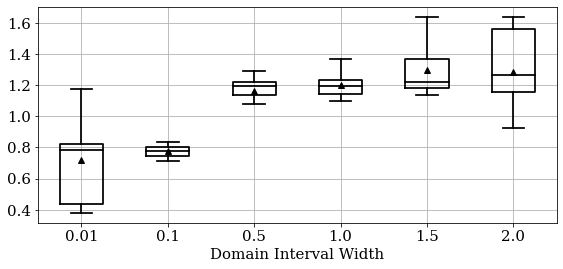

In [14]:

boxplot_utils.make_boxplot(
    'plots/runtime_generate_coefs_wrt_interval_width.png',
    results_df,
    xcol='domain_interval_width', ycol='runtime_to_generate_amie_coefs',
    lw=1.75, color='k',
    figsize=(9,4), fontsize=15,
    xlabel='Domain Interval Width')